## 2. Obtención y almacenamiento de los datos

### Requisitos:

- Obtener los datos según las variables seleccionadas en el apartado anterior.
- Integrar datos provenientes de múltiples fuentes con diferente estructura.
- Diseñar una arquitectura de datos que integre todas las fuentes en un repositorio único.
- Justificar la elección del sistema de almacenamiento
- Todo el sistema de ingestión, procesamiento y almacenamiento debe poder ejecutarse mediante un único script que:
  - Despliegue la arquitectura.
  - Ingestione los datos.
  - Procese y unifique la información.

### Tecnologías obligatorias:

- Uso de herramientas ETL/ELT como:
  - Apache NiFi
  - AWS Glue
  - Amazon Athena

- Uso de servicios AWS mediante `boto3`:
  - Amazon S3 para almacenamiento de datos.
  - Amazon RDS para datos estructurados.
  - AWS Lambda para automatización de procesos.

- Uso de bases de datos NoSQL:
  - MongoDB Atlas o Amazon DocumentDB.

- Procesamiento de datos en tiempo real:
  - Apache Kafka.

Los pasos correspondientes a esta fase del proyecto han sido completamente integrados en el script de producción localizado en la raíz del repositorio.

Debido a la envergadura y complejidad del procesamiento, ejecutar este bloque de código dentro del entorno del notebook resulta ineficiente. Por tanto, el trabajo pesado se delega al script **pipeline_noticias.py**, el cual consolida la arquitectura de datos del proyecto.

## 3. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo que incluya al menos lo siguiente:

- Inspección inicial:
  - Mostrar los primeros 5 registros de cada dataset
  - Análisis del contenido de cada columna

- Estadísticas descriptivas:
  - Media
  - Mediana
  - Moda
  - Desviación estándar
  - Percentiles

- Identificación de patrones, anomalías o valores atípicos

- Visualización de datos utilizando las gráficas más adecuadas:
  - Histogramas
  - Diagramas de dispersión
  - Boxplots
  - Gráficos de correlación
  - Etcétera

- Análisis de correlaciones entre variables

## Importaciones

In [ ]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import re
from collections import Counter

# ── Manipulación de datos ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from dateutil import parser as dateutil_parser

# ── Scikit-learn ──────────────────────────────────────────────────────────────
import joblib
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.svm import LinearSVC

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

# ── Hugging Face / Transformers ───────────────────────────────────────────────
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── Utilidades ────────────────────────────────────────────────────────────────
import shutil

2026-06-02 21:53:28.453716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780437208.709053      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780437208.780474      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780437209.358029      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780437209.358066      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780437209.358069      58 computation_placer.cc:177] computation placer alr

## Carga de datos

In [ ]:
df = pd.read_csv(
    "/kaggle/input/datasets/victor685/dataset/raw_news_combined.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)

(89437, 7)


## Primeros registros

In [ ]:
df.head(5)

,id,source,title,content_clean,published_at,label,ingested_at
0,1,newsapi,"From Cisco to Block, more companies are pointi...",NEW YORK -- NEW YORK (AP) Layoffs have been pi...,2026-05-15T12:04:00Z,NaN,2026-05-16 12:18:45
1,2,newsapi,Safe Pro Reports Record 560% Revenue Growth in...,"AVENTURA, Fla., May 15, 2026 (GLOBE NEWSWIRE) ...",2026-05-15T12:02:00Z,NaN,2026-05-16 12:18:45
2,3,newsapi,Newsom outlines his final budget proposal with...,"SACRAMENTO, Calif. -- California Gov. Gavin Ne...",2026-05-15T12:01:37Z,NaN,2026-05-16 12:18:45
3,4,newsapi,"Dire Colorado budget, business wins and veto t...",The final legislative session of Colorado Gov....,2026-05-15T12:00:50Z,NaN,2026-05-16 12:18:45
4,5,newsapi,"Detroit automakers have cut more than 20,000 U...",The former General Motors headquarters inside ...,2026-05-15T12:00:01Z,NaN,2026-05-16 12:18:45


## Visualización de información más general

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89437 entries, 0 to 89436
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             89437 non-null  int64 
 1   source         89437 non-null  object
 2   title          89437 non-null  object
 3   content_clean  88806 non-null  object
 4   published_at   89437 non-null  object
 5   label          89165 non-null  object
 6   ingested_at    89437 non-null  object
dtypes: int64(1), object(6)
memory usage: 4.8+ MB


## Eliminación de Stopswords

In [ ]:
nltk.download('stopwords')

stop_words_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def remover_stopwords(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'<.*?>', '', texto)  # eliminar HTML
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)  # solo letras
    palabras = str(texto).lower().split()
    palabras_limpias = [p for p in palabras if p not in stop_words_en]
    return " ".join(palabras_limpias)

df['content_clean'] = df['content_clean'].apply(remover_stopwords)
df['title'] = df['title'].apply(remover_stopwords)
df.head()

,id,source,title,content_clean,published_at,label,ingested_at
0,1,newsapi,cisco block companies pointing ai unveiling jo...,new york new york ap layoffs piling recently e...,2026-05-15T12:04:00Z,NaN,2026-05-16 12:18:45
1,2,newsapi,safe pro reports record revenue growth first q...,aventura fla may globe newswire safe pro group...,2026-05-15T12:02:00Z,NaN,2026-05-16 12:18:45
2,3,newsapi,newsom outlines final budget proposal deficit ...,sacramento calif california gov gavin newsom t...,2026-05-15T12:01:37Z,NaN,2026-05-16 12:18:45
3,4,newsapi,dire colorado budget business wins veto threat...,final legislative session colorado gov jared p...,2026-05-15T12:00:50Z,NaN,2026-05-16 12:18:45
4,5,newsapi,detroit automakers cut us salaried jobs ai thr...,former general motors headquarters inside rena...,2026-05-15T12:00:01Z,NaN,2026-05-16 12:18:45


## Ver palabras más repetidas

In [ ]:
df_filtrado = df[df["label"].notna()].copy()

# Ver labels disponibles
print(df_filtrado["label"].unique())

['Fake' 'Real']


### Fake

In [ ]:
df_fake = df_filtrado[df_filtrado["label"] == "Fake"]

texto_fake = " ".join(df_fake["content_clean"].dropna())

palabras_fake = texto_fake.split()

contador_fake = Counter(palabras_fake)

top_fake = contador_fake.most_common(20)

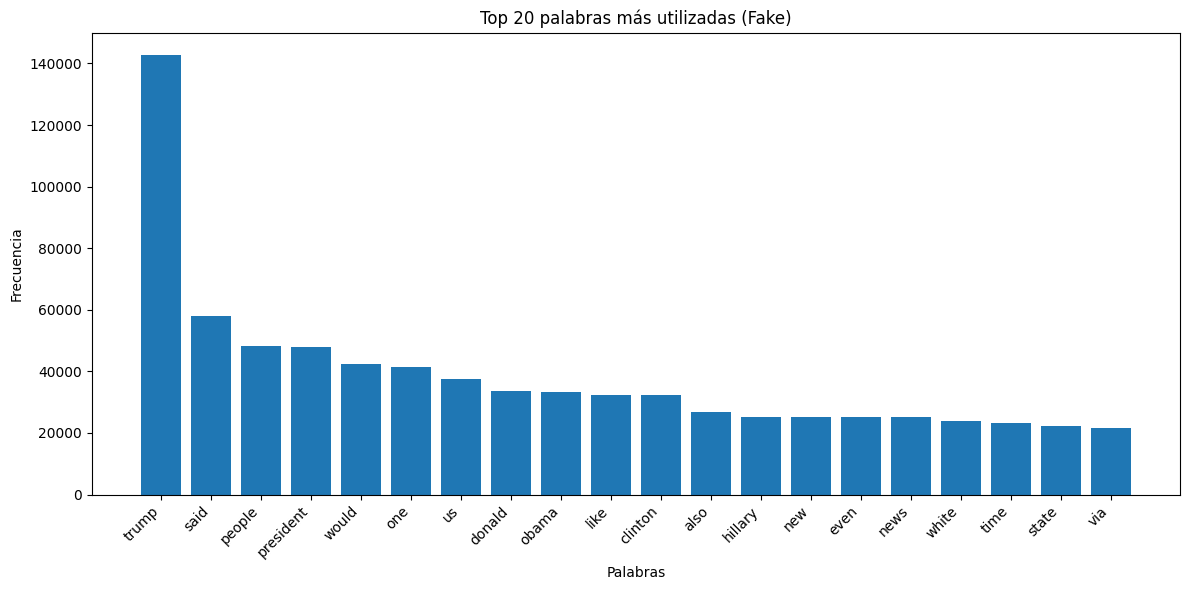

In [ ]:
# Preparar gráfico fake
palabras_top_fake = [p[0] for p in top_fake]
frecuencias_top_fake = [p[1] for p in top_fake]

plt.figure(figsize=(12,6))

plt.bar(palabras_top_fake, frecuencias_top_fake)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Frecuencia")
plt.xlabel("Palabras")
plt.title("Top 20 palabras más utilizadas (Fake)")

plt.tight_layout()
plt.show()

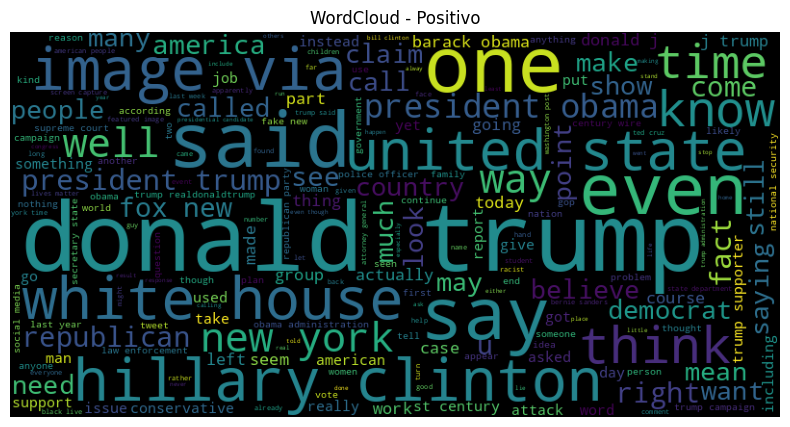

In [ ]:
plt.figure(figsize=(10,5))
wc = WordCloud(width=800, height=400).generate(texto_fake)
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - Positivo")
plt.show()

### Real

In [ ]:
df_real = df_filtrado[df_filtrado["label"] == "Real"]

texto_real = " ".join(df_real["content_clean"].dropna())

palabras_real = texto_real.split()

contador_real = Counter(palabras_real)

top_real = contador_real.most_common(20)

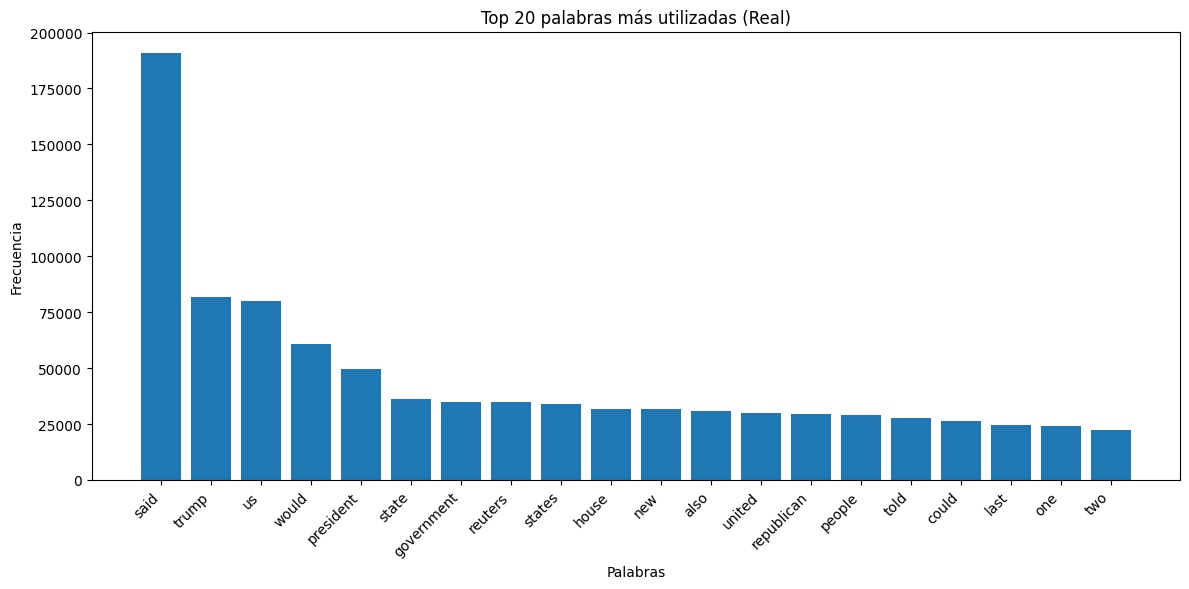

In [ ]:
palabras_top_real = [p[0] for p in top_real]
frecuencias_top_real = [p[1] for p in top_real]

# Gráfico
plt.figure(figsize=(12,6))

plt.bar(palabras_top_real, frecuencias_top_real)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Frecuencia")
plt.xlabel("Palabras")
plt.title("Top 20 palabras más utilizadas (Real)")

plt.tight_layout()
plt.show()

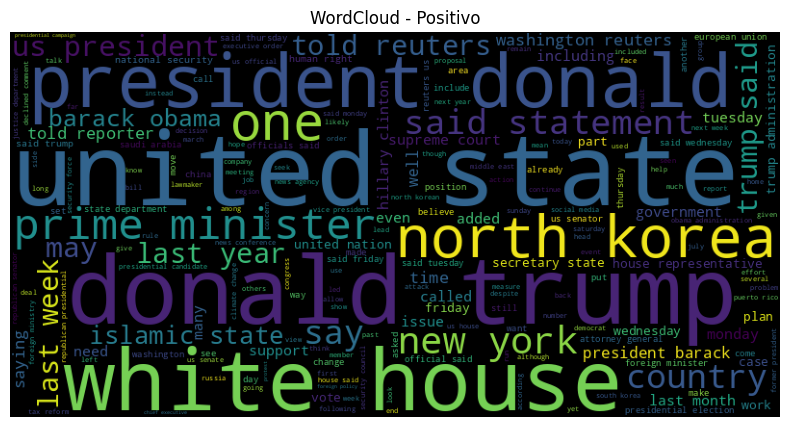

In [ ]:
plt.figure(figsize=(10,5))
wc = WordCloud(width=800, height=400).generate(texto_real)
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - Positivo")
plt.show()

## Descripción de las columnas

Vamos a describir unicamente las columnas más importantes y que nos puedan dar datos reales ya que si ponemos los titulos o los textos esta descripción no es buena

In [ ]:
def describe_columna(df, columna, top_n=20):
    """
    Muestra información descriptiva de una columna de un DataFrame.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame a analizar.

    columna : str
        Nombre de la columna.

    top_n : int
        Número máximo de valores únicos a mostrar.
    """

    if columna not in df.columns:
        print(f"La columna '{columna}' no existe en el DataFrame.")
        return

    print("=" * 60)
    print(f"DESCRIPCIÓN DE LA COLUMNA: {columna}")
    print("=" * 60)

    # Tipo de dato
    print(f"\nTipo de dato: {df[columna].dtype}")

    # Valores nulos
    nulos = df[columna].isnull().sum()
    print(f"\nValores nulos: {nulos}")

    # Valores únicos
    unicos = df[columna].nunique(dropna=True)
    print(f"Valores únicos: {unicos}")

    # Ejemplos
    print(f"\nPrimeros 5 valores:")
    print(df[columna].head())

    # Frecuencia de valores
    print(f"\nTop {top_n} valores más frecuentes:")
    print(df[columna].value_counts(dropna=False).head(top_n))

    # Porcentaje de valores únicos
    porcentaje_unicos = (unicos / len(df)) * 100
    print(f"\nPorcentaje de valores únicos: {porcentaje_unicos:.2f}%")

    # Longitud media si es texto
    if df[columna].dtype == "object":
        try:
            longitud_media = df[columna].dropna().astype(str).apply(len).mean()
            print(f"Longitud media del texto: {longitud_media:.2f} caracteres")
        except:
            pass

    print("\n" + "=" * 60)

In [ ]:
describe_columna(df, "source", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: source

Tipo de dato: object

Valores nulos: 0
Valores únicos: 3

Primeros 5 valores:
0    newsapi
1    newsapi
2    newsapi
3    newsapi
4    newsapi
Name: source, dtype: object

Top 20 valores más frecuentes:
source
kaggle         44898
huggingface    44267
newsapi          272
Name: count, dtype: int64

Porcentaje de valores únicos: 0.00%
Longitud media del texto: 8.48 caracteres



In [ ]:
describe_columna(df, "label", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: label

Tipo de dato: object

Valores nulos: 272
Valores únicos: 2

Primeros 5 valores:
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: label, dtype: object

Top 20 valores más frecuentes:
label
Fake    46332
Real    42833
NaN       272
Name: count, dtype: int64

Porcentaje de valores únicos: 0.00%
Longitud media del texto: 4.00 caracteres



## Generación de columnas descriptivas

Vamos a generar columnas descriptivas sobre la longitud de palabras y de caracteres

In [ ]:
df['title_len'] = df['title'].fillna('').apply(len)
df['content_len'] = df['content_clean'].fillna('').apply(len)

df['title_word_count'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['content_word_count'] = df['content_clean'].fillna('').apply(lambda x: len(x.split()))


In [ ]:
df.head()

,id,source,title,content_clean,published_at,label,ingested_at,title_len,content_len,title_word_count,content_word_count
0,1,newsapi,cisco block companies pointing ai unveiling jo...,new york new york ap layoffs piling recently e...,2026-05-15T12:04:00Z,NaN,2026-05-16 12:18:45,52,139,8,20
1,2,newsapi,safe pro reports record revenue growth first q...,aventura fla may globe newswire safe pro group...,2026-05-15T12:02:00Z,NaN,2026-05-16 12:18:45,116,158,16,22
2,3,newsapi,newsom outlines final budget proposal deficit ...,sacramento calif california gov gavin newsom t...,2026-05-15T12:01:37Z,NaN,2026-05-16 12:18:45,64,156,9,22
3,4,newsapi,dire colorado budget business wins veto threat...,final legislative session colorado gov jared p...,2026-05-15T12:00:50Z,NaN,2026-05-16 12:18:45,94,172,14,23
4,5,newsapi,detroit automakers cut us salaried jobs ai thr...,former general motors headquarters inside rena...,2026-05-15T12:00:01Z,NaN,2026-05-16 12:18:45,55,164,9,19


In [ ]:
df.describe()

,id,title_len,content_len,title_word_count,content_word_count
count,89437.00000,89437.000000,89437.000000,89437.000000,89437.000000
mean,44719.00000,65.381129,1609.200722,9.313942,213.120565
std,25818.38235,19.776660,973.590956,2.727356,127.958262
min,1.00000,8.000000,0.000000,1.000000,0.000000
25%,22360.00000,53.000000,872.000000,8.000000,117.000000
50%,44719.00000,61.000000,1515.000000,9.000000,202.000000
75%,67078.00000,73.000000,2162.000000,10.000000,286.000000
max,89437.00000,238.000000,4324.000000,29.000000,562.000000


In [ ]:
numeric_cols = ['title_len', 'content_len', 'title_word_count', 'content_word_count']

print("--- ESTADÍSTICAS DESCRIPTIVAS DETALLADAS ---")
for col in numeric_cols:
    print(f"\nVariable: {col}")
    print(f"  • Media (μ):               {df[col].mean():.2f}")
    print(f"  • Mediana (p50):           {df[col].median():.2f}")
    print(f"  • Moda:                    {df[col].mode()[0] if not df[col].mode().empty else 'No posee'}")
    print(f"  • Desviación Estándar (σ): {df[col].std():.2f}")
    print(f"  • Percentil 25 (Q1):       {df[col].quantile(0.25):.2f}")
    print(f"  • Percentil 50 (Q2):       {df[col].quantile(0.50):.2f}")
    print(f"  • Percentil 75 (Q3):       {df[col].quantile(0.75):.2f}")

# Resumen rápido utilizando la función nativa de pandas
print("\n--- CUADRO RESUMEN GLOBAL ---")
display(df[numeric_cols].describe())

--- ESTADÍSTICAS DESCRIPTIVAS DETALLADAS ---

Variable: title_len
  • Media (μ):               65.38
  • Mediana (p50):           61.00
  • Moda:                    58
  • Desviación Estándar (σ): 19.78
  • Percentil 25 (Q1):       53.00
  • Percentil 50 (Q2):       61.00
  • Percentil 75 (Q3):       73.00

Variable: content_len
  • Media (μ):               1609.20
  • Mediana (p50):           1515.00
  • Moda:                    0
  • Desviación Estándar (σ): 973.59
  • Percentil 25 (Q1):       872.00
  • Percentil 50 (Q2):       1515.00
  • Percentil 75 (Q3):       2162.00

Variable: title_word_count
  • Media (μ):               9.31
  • Mediana (p50):           9.00
  • Moda:                    8
  • Desviación Estándar (σ): 2.73
  • Percentil 25 (Q1):       8.00
  • Percentil 50 (Q2):       9.00
  • Percentil 75 (Q3):       10.00

Variable: content_word_count
  • Media (μ):               213.12
  • Mediana (p50):           202.00
  • Moda:                    0
  • Desviación Estánd

,title_len,content_len,title_word_count,content_word_count
count,89437.000000,89437.000000,89437.000000,89437.000000
mean,65.381129,1609.200722,9.313942,213.120565
std,19.776660,973.590956,2.727356,127.958262
min,8.000000,0.000000,1.000000,0.000000
25%,53.000000,872.000000,8.000000,117.000000
50%,61.000000,1515.000000,9.000000,202.000000
75%,73.000000,2162.000000,10.000000,286.000000
max,238.000000,4324.000000,29.000000,562.000000


In [ ]:
print("\n--- IDENTIFICACIÓN DE VALORES ATÍPICOS (OUTLIERS MEDIANTE IQR) ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Variable '{col}': Se encontraron {len(outliers)} registros atípicos (Fuera del rango [{limite_inferior:.1f}, {limite_superior:.1f}])")


--- IDENTIFICACIÓN DE VALORES ATÍPICOS (OUTLIERS MEDIANTE IQR) ---
Variable 'title_len': Se encontraron 5208 registros atípicos (Fuera del rango [23.0, 103.0])
Variable 'content_len': Se encontraron 30 registros atípicos (Fuera del rango [-1063.0, 4097.0])
Variable 'title_word_count': Se encontraron 7535 registros atípicos (Fuera del rango [5.0, 13.0])
Variable 'content_word_count': Se encontraron 28 registros atípicos (Fuera del rango [-136.5, 539.5])


# Visualización de graficos

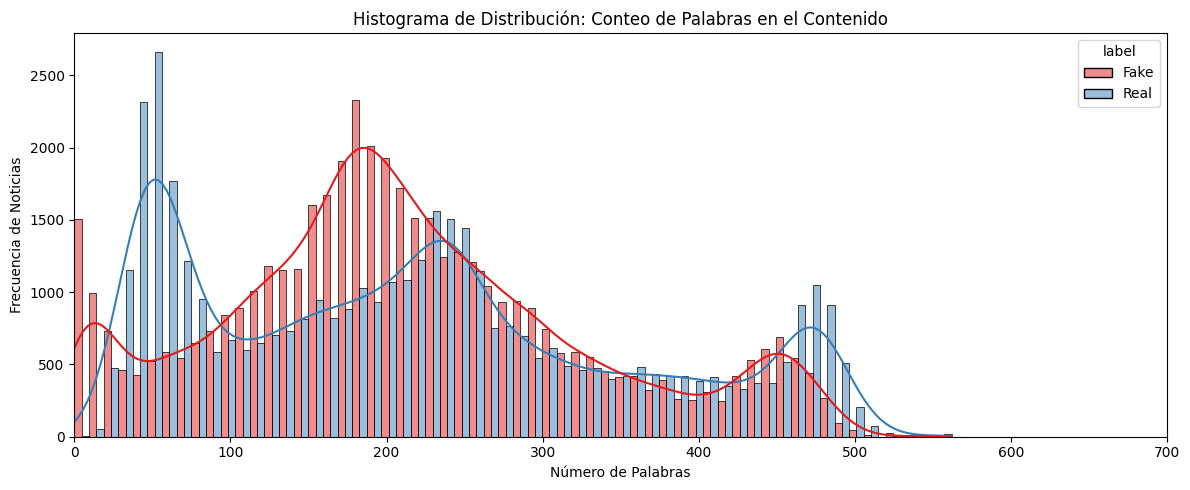

In [ ]:
plt.figure(figsize=(12, 5))
# Acotamos el eje X a 1500 palabras para evitar que outliers extremos distorsionen la visualización de la masa crítica
sns.histplot(data=df, x='content_word_count', hue='label', bins=60, kde=True, multiple="dodge", palette="Set1")
plt.xlim(0, 700)
plt.title('Histograma de Distribución: Conteo de Palabras en el Contenido')
plt.xlabel('Número de Palabras')
plt.ylabel('Frecuencia de Noticias')
plt.tight_layout()


plt.show()

/tmp/ipykernel_58/1534377678.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='title_len', data=df_plot, ax=axes[0, 0], palette=palette)
/tmp/ipykernel_58/1534377678.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='content_len', data=df_plot, ax=axes[0, 1], palette=palette)
/tmp/ipykernel_58/1534377678.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='title_word_count', data=df_plot, ax=axes[1, 0], palette=palette)
/tmp/ipykernel_58/1534377678.py:31: FutureWarning: 

Passing `palette` witho

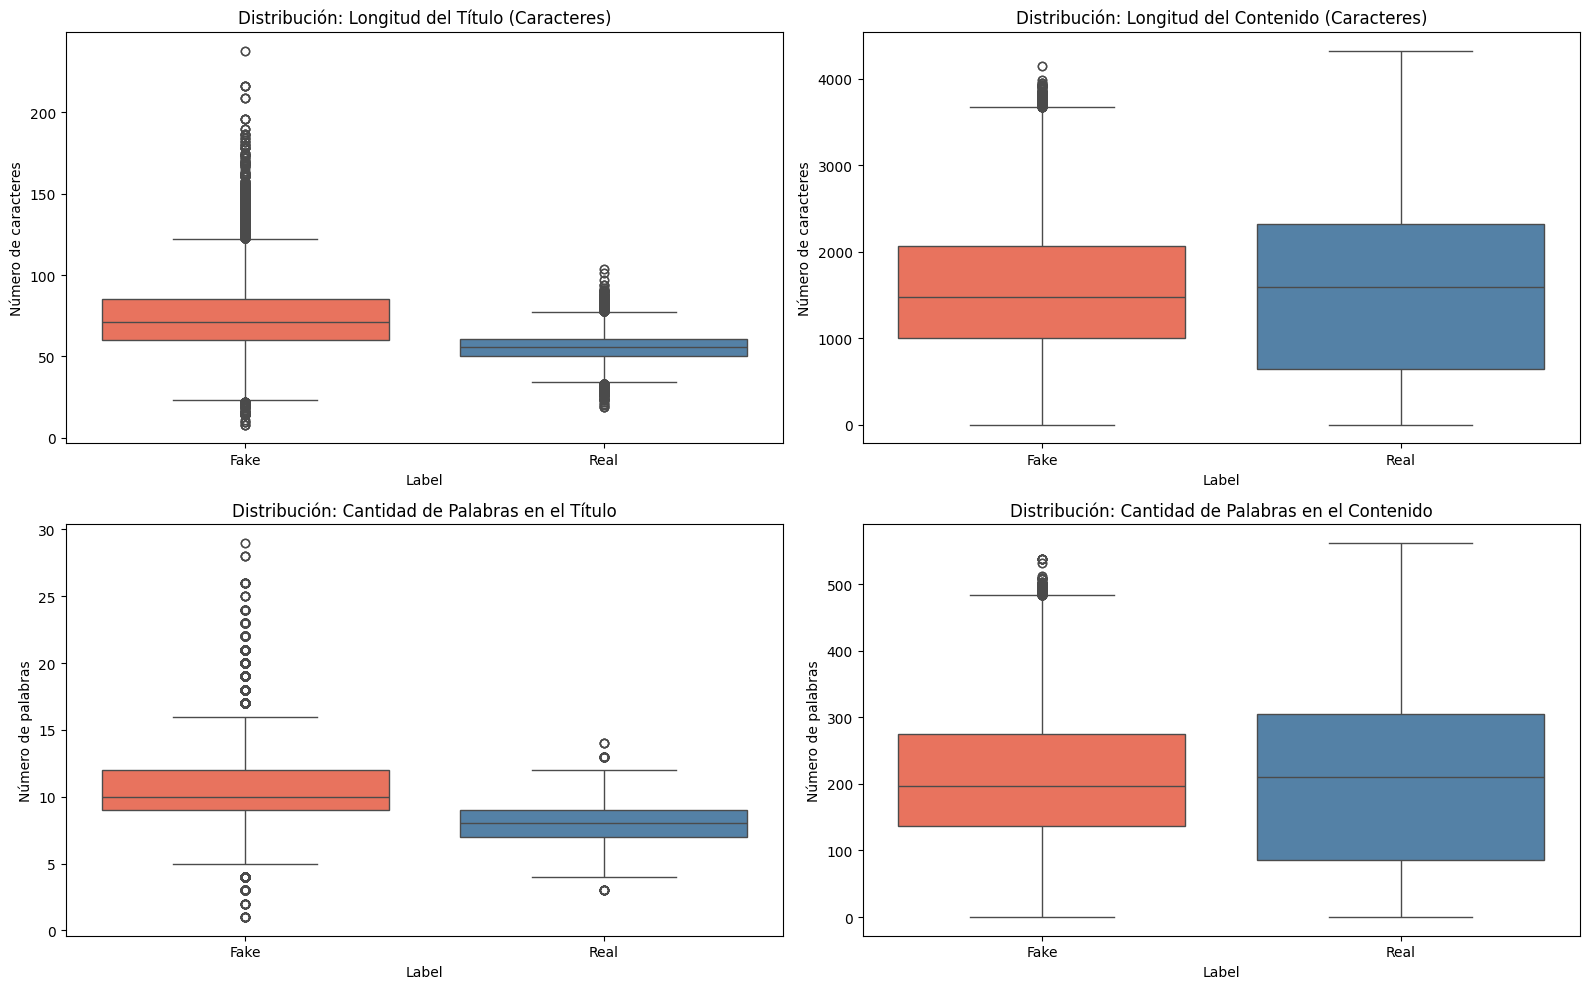

In [ ]:
# Eliminar filas con NaN en label
df_plot = df.dropna(subset=['label'])

# Mapear etiquetas
if df_plot['label'].dtype in ['int64', 'float64']:
    df_plot['label'] = df_plot['label'].map({0: 'Fake', 1: 'Real'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

palette = {'Real': 'steelblue', 'Fake': 'tomato'}

# 1. Boxplot: Longitud del Título (Caracteres)
sns.boxplot(x='label', y='title_len', data=df_plot, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('Distribución: Longitud del Título (Caracteres)')
axes[0, 0].set_xlabel('Label')
axes[0, 0].set_ylabel('Número de caracteres')

# 2. Boxplot: Longitud del Contenido (Caracteres)
sns.boxplot(x='label', y='content_len', data=df_plot, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('Distribución: Longitud del Contenido (Caracteres)')
axes[0, 1].set_xlabel('Label')
axes[0, 1].set_ylabel('Número de caracteres')

# 3. Boxplot: Palabras en el Título
sns.boxplot(x='label', y='title_word_count', data=df_plot, ax=axes[1, 0], palette=palette)
axes[1, 0].set_title('Distribución: Cantidad de Palabras en el Título')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Número de palabras')

# 4. Boxplot: Palabras en el Contenido
sns.boxplot(x='label', y='content_word_count', data=df_plot, ax=axes[1, 1], palette=palette)
axes[1, 1].set_title('Distribución: Cantidad de Palabras en el Contenido')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Número de palabras')

plt.tight_layout()
plt.show()

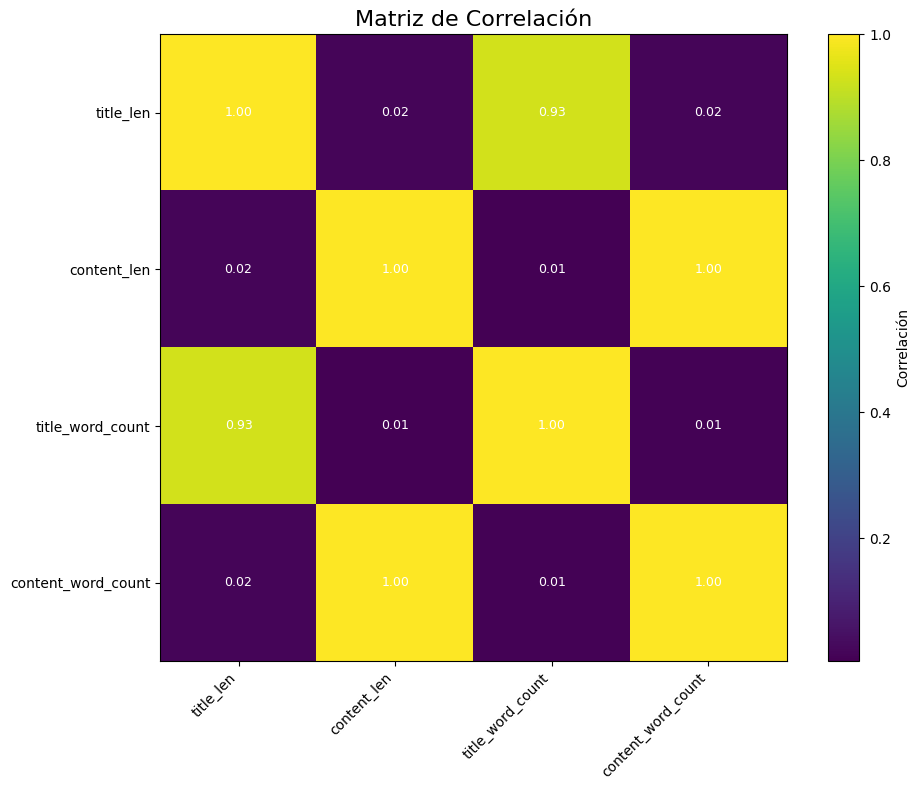

In [ ]:
matriz_corr = df[numeric_cols].corr()

# Crear figura
plt.figure(figsize=(10, 8))

# Heatmap
im = plt.imshow(matriz_corr, cmap="viridis")

# Barra lateral
plt.colorbar(im, label="Correlación")

# Etiquetas
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)

# Añadir valores dentro de cada celda
for i in range(len(matriz_corr)):
    for j in range(len(matriz_corr.columns)):
        plt.text(
            j,
            i,
            f"{matriz_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9
        )

# Título
plt.title("Matriz de Correlación", fontsize=16)

plt.tight_layout()
plt.show()

## Noticias Vacias

He observado que hay registros cuyo contenido es nulo es decir que esta vacio. Vamos a ver más en detalle esto y continuaremos

In [ ]:
# Crear un nuevo DataFrame con las filas donde content_word_count == 0
df_content_vacio = df[df["content_word_count"] == 0].copy()

# Mostrar cantidad de resultados
print(f"Filas con content_word_count = 0: {len(df_content_vacio)}")

# Mostrar ejemplos
display(df_content_vacio.head(10))

Filas con content_word_count = 0: 633


,id,source,title,content_clean,published_at,label,ingested_at,title_len,content_len,title_word_count,content_word_count
11059,11060,kaggle,take poll think president trump pick replace j...,,"May 10, 2017",Fake,2026-05-17 16:06:51,56,0,9,0
11177,11178,kaggle,joe scarborough berates mika brzezinski cheap ...,,"Apr 26, 2017",Fake,2026-05-17 16:06:51,81,0,12,0
11326,11327,kaggle,watch tucker carlson scorch sanctuary city may...,,"Apr 6, 2017",Fake,2026-05-17 16:06:51,72,0,11,0
11361,11362,kaggle,mayor sanctuary city trump trying make us fugi...,,"Apr 2, 2017",Fake,2026-05-17 16:06:51,71,0,11,0
11372,11373,kaggle,shocker public school turns computer lab mosqu...,,"Apr 1, 2017",Fake,2026-05-17 16:06:51,76,0,10,0
11377,11378,kaggle,boom sean spicer trump sold hotels russia hill...,,"Mar 31, 2017",Fake,2026-05-17 16:06:51,70,0,11,0
11383,11384,kaggle,michael flynns lawyer releases statement scorc...,,"Mar 30, 2017",Fake,2026-05-17 16:06:51,80,0,10,0
11385,11386,kaggle,rob schneider nails russia conspiracy theorist...,,"Mar 30, 2017",Fake,2026-05-17 16:06:51,68,0,9,0
11403,11404,kaggle,trey gowdy spying american citizenslike presid...,,"Mar 28, 2017",Fake,2026-05-17 16:06:51,61,0,8,0
11404,11405,kaggle,sean spicer calls race baiting journalist stop...,,"Mar 28, 2017",Fake,2026-05-17 16:06:51,65,0,10,0


In [ ]:
describe_columna(df_content_vacio, "label", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: label

Tipo de dato: object

Valores nulos: 0
Valores únicos: 2

Primeros 5 valores:
11059    Fake
11177    Fake
11326    Fake
11361    Fake
11372    Fake
Name: label, dtype: object

Top 20 valores más frecuentes:
label
Fake    632
Real      1
Name: count, dtype: int64

Porcentaje de valores únicos: 0.32%
Longitud media del texto: 4.00 caracteres



In [ ]:
describe_columna(df_content_vacio, "source", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: source

Tipo de dato: object

Valores nulos: 0
Valores únicos: 2

Primeros 5 valores:
11059    kaggle
11177    kaggle
11326    kaggle
11361    kaggle
11372    kaggle
Name: source, dtype: object

Top 20 valores más frecuentes:
source
kaggle         632
huggingface      1
Name: count, dtype: int64

Porcentaje de valores únicos: 0.32%
Longitud media del texto: 6.01 caracteres



# Conclusión

## Conclusiones del Análisis Exploratorio de Datos (EDA)

Este apartado ha permitido profundizar en la estructura del dataset, desvelando patrones lógicos y anomalías clave que guiarán las siguientes etapas del proyecto. A continuación, se detallan los hallazgos más relevantes:

### 1. Calidad de los Datos y Limpieza Inmediata
* **Registros vacíos:** Se identificaron ciertos registros que carecen de contenido en el cuerpo de la noticia (`content_clean`). Dado que no aportan información al análisis semántico ni al entrenamiento de modelos, **estos registros serán eliminados en la sección de preprocesamiento.**

### 2. Patrones en la Longitud del Texto (Reales vs. Falsas)
Se observó un comportamiento sumamente interesante al analizar la distribución del conteo de palabras según la veracidad de la noticia:
* **Rango de 0 a 100 palabras:** Existe una marcada predominancia de noticias **Reales**.
* **Rango de 100 a 250 palabras:** Tienden a sobresalir de manera evidente las noticias **Falsas**.
* **Más de 250 palabras:** La frontera se diluye, volviendo más compleja la diferenciación visual de qué clase predomina.

>**Implicación:** La longitud del texto por sí sola actúa como un predictor débil pero útil en rangos específicos, lo que demuestra que las noticias falsas analizadas tienden a mantener una extensión intermedia estandarizada.

### 3. Análisis Léxico y Palabras Más Frecuentes
Al extraer los términos más comunes (tras la eliminación de *stopwords*), la palabra **"Trump"** se posiciona como el núcleo indiscutible del dataset, tanto en la categoría de reales como de falsas.
* Esto guarda total coherencia con el contexto del dataset, centrado en la política del gigante americano.
* Sin embargo, resulta sorprendente **lo mucho que sobresale este término en el subconjunto de noticias falsas**, sugiriendo que la figura del presidente es el foco principal para la generación de desinformación en la muestra.

### 4. Análisis de Correlación
* El estudio a través de las matrices de correlación no reveló dependencias ocultas o inesperadas.
* Las únicas correlaciones fuertes encontradas corresponden a variables intrínsecamente ligadas (como la longitud en caracteres del título frente a su número de palabras). Este comportamiento es **obvio y esperable**, confirmando la consistencia geométrica de los datos pero sin aportar variables numéricas redundantes de alto impacto para el modelado.

## 4. Preparación del conjunto de datos

### Integración de datos
- Unificación de múltiples datasets
- Resolución de inconsistencias:
  - Tipos de datos
  - Duplicados
  - Conflictos entre fuentes

### Limpieza de datos:

- Eliminación de variables irrelevantes:
  - Basado en correlación o criterio experto

- Manejo de valores faltantes:
  - Imputación (media, mediana, moda, cero, etc.).
  - Eliminación de filas/columnas si procede

- Tratamiento de valores duplicados

- Tratamiento de valores atípicos:
  - Eliminación o corrección

- Adecuación de los tipos de datos

- Gestión de inconsistencias

### Ingeniería de características:

- Discretización de variables continuas.
- Descomposición de variables:
  - Fechas (día, mes, año, hora).
  - Variables categóricas complejas.
- Transformaciones:
  - log(x)
  - sqrt(x)
  - x²
- Creación de nuevas variables combinadas.
- Escalado de características:
  - Normalización o estandarización.
- Encoding de variables categóricas:
  - Label Encoding
  - One-Hot Encoding
  - Embedding

### División del dataset:

- Separar en:
  - Entrenamiento (80%)
  - Test (20%)


## Integración de datos

Los datos ya se integraron todos en el script inicial por lo que ahora mismo solo tengo un unico dataset

In [ ]:
df.dtypes

id                     int64
source                object
title                 object
content_clean         object
published_at          object
label                 object
ingested_at           object
title_len              int64
content_len            int64
title_word_count       int64
content_word_count     int64
dtype: object

## Cambio de tipo de datos

In [ ]:
describe_columna(df, "published_at", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: published_at

Tipo de dato: object

Valores nulos: 0
Valores únicos: 2454

Primeros 5 valores:
0    2026-05-15T12:04:00Z
1    2026-05-15T12:02:00Z
2    2026-05-15T12:01:37Z
3    2026-05-15T12:00:50Z
4    2026-05-15T12:00:01Z
Name: published_at, dtype: object

Top 20 valores más frecuentes:
published_at
December 20, 2017      364
December 6, 2017       332
November 30, 2017      324
November 9, 2017       316
October 13, 2017       310
September 21, 2017     306
September 6, 2017      302
December 21, 2017      302
September 7, 2017      298
September 22, 2017     292
October 19, 2017       290
September 12, 2017     286
November 8, 2017       286
October 26, 2017       284
October 18, 2017       284
September 15, 2017     282
October 16, 2017       282
December 7, 2017       280
October 24, 2017       278
October 12, 2017       274
Name: count, dtype: int64

Porcentaje de valores únicos: 2.74%
Longitud media del texto: 14.86 caracteres



In [ ]:
def detectar_formato(valor):
    if pd.isna(valor):
        return "nulo"
    v = str(valor).strip()
    if re.match(r'^\w+ \d{1,2}, \d{4}$', v):
        return "December 20, 2017"
    if re.match(r'^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z$', v):
        return "ISO 8601 con Z"
    if re.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$', v):
        return "datetime sin zona"
    return f"desconocido: {v[:30]}"

# Ver distribución de formatos
print(df['published_at'].apply(detectar_formato).value_counts())

published_at
December 20, 2017                              89075
ISO 8601 con Z                                   272
desconocido: 15-Feb-18                            18
desconocido: 16-Feb-18                            16
desconocido: 18-Feb-18                            14
desconocido: 17-Feb-18                            14
desconocido: https://fedup.wpengine.com/wp-       12
desconocido: 19-Feb-18                             6
desconocido: 14-Feb-18                             2
desconocido: https://100percentfedup.com/se        2
desconocido: https://100percentfedup.com/vi        2
desconocido: https://100percentfedup.com/12        2
desconocido: MSNBC HOST Rudely Assumes Stee        2
Name: count, dtype: int64


In [ ]:
FORMATOS = [
    "%B %d, %Y",           # December 20, 2017
    "%Y-%m-%dT%H:%M:%SZ",  # 2026-05-15T12:04:00Z
    "%Y-%m-%d %H:%M:%S",   # 2026-05-17 16:06:51
    "%Y-%m-%d",            # 2026-05-17
    "%d-%b-%y",            # 14-Feb-18
    "%d-%b-%Y",            # 14-Feb-2018 (por si acaso)
]

# Patrones que claramente NO son fechas
PATRON_NO_FECHA = re.compile(
    r'^https?://'                        # URLs
    r'|^\d{1,2}\s+[A-Z]'               # evita falsos positivos
    r'|^[A-Z]{2,}\s+[A-Z]',            # Frases en mayúsculas tipo "MSNBC HOST..."
    re.IGNORECASE
)

def parsear_fecha(valor):
    if pd.isna(valor):
        return pd.NaT

    valor_str = str(valor).strip()

    # Descartar lo que claramente no es una fecha
    if PATRON_NO_FECHA.search(valor_str):
        return pd.NaT

    # Intentar cada formato conocido
    for fmt in FORMATOS:
        try:
            return pd.to_datetime(valor_str, format=fmt)
        except (ValueError, TypeError):
            continue

    # Fallback con dateutil
    try:
        return pd.to_datetime(dateutil_parser.parse(valor_str))
    except Exception:
        print(f"⚠️  Sin parsear: {valor_str!r}")
        return pd.NaT


df['published_at'] = df['published_at'].apply(parsear_fecha)

# Verificación rápida
print(df['published_at'].dtype)
print(df['published_at'].isna().sum(), "valores nulos (URLs, títulos, etc.)")
print(df['published_at'].notna().sum(), "fechas convertidas correctamente")

datetime64[ns]
20 valores nulos (URLs, títulos, etc.)
89417 fechas convertidas correctamente


In [ ]:
df['published_at'] = df['published_at'].dt.normalize()

In [ ]:
describe_columna(df, "published_at", top_n=20)

DESCRIPCIÓN DE LA COLUMNA: published_at

Tipo de dato: datetime64[ns]

Valores nulos: 20
Valores únicos: 1011

Primeros 5 valores:
0   2026-05-15
1   2026-05-15
2   2026-05-15
3   2026-05-15
4   2026-05-15
Name: published_at, dtype: datetime64[ns]

Top 20 valores más frecuentes:
published_at
2017-12-20    394
2017-12-06    366
2017-11-09    364
2017-11-30    356
2017-09-15    344
2017-10-13    344
2017-09-07    342
2017-09-06    340
2017-11-08    340
2017-12-21    338
2017-09-21    336
2017-10-19    336
2017-09-26    330
2017-10-26    328
2017-09-22    328
2017-10-12    322
2017-10-24    322
2017-10-18    322
2017-09-12    318
2017-12-07    314
Name: count, dtype: int64

Porcentaje de valores únicos: 1.13%



## Duplicado de datos

Hemos encontrado muchas noticias repetidas las cuales se incluyen las vacias

In [ ]:
print("--- DETECCIÓN DE DUPLICADOS ---")
print(f"Filas iniciales: {len(df)}")

# Detectar filas duplicadas según el contenido
mask_duplicados = df.duplicated(subset=['content_clean'], keep=False)

# Mostrar algunos duplicados
duplicados_df = df[mask_duplicados].sort_values(by='content_clean')

print("\n--- EJEMPLOS DE DUPLICADOS ---")
print(duplicados_df[['content_clean']].head(10))

# Mostrar índices (número de fila)
print("\n--- ÍNDICES DE FILAS DUPLICADAS ---")
print(duplicados_df.index.tolist()[:20])

# Cantidad total
duplicados = df.duplicated(subset=['content_clean']).sum()

print(f"\nArtículos duplicados detectados: {duplicados}")

# Eliminar duplicados conservando el primero
df.drop_duplicates(subset=['content_clean'], inplace=True)

print(f"Filas tras eliminar duplicados: {len(df)}")

--- DETECCIÓN DE DUPLICADOS ---
Filas iniciales: 89437

--- EJEMPLOS DE DUPLICADOS ---
      content_clean
12844              
11928              
14418              
14222              
11929              
11939              
11942              
14099              
11949              
11957              

--- ÍNDICES DE FILAS DUPLICADAS ---
[12844, 11928, 14418, 14222, 11929, 11939, 11942, 14099, 11949, 11957, 11967, 11968, 13802, 13750, 11977, 11980, 11984, 13610, 11990, 11994]

Artículos duplicados detectados: 29594
Filas tras eliminar duplicados: 59843


## Eliminar Vacias
Eliminamos las vacias que quedan despues de eliminar los duplicados

In [ ]:
df['content_clean'] = (
    df['content_clean']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df = df[df['content_clean'] != '']

## Eliminar Outliers
Eliminar Textos que contengan menos de 12 palabras sin stpwors. Lo que equivale a un parrafo de unas 30-40 palabras

In [ ]:
# Filtrar noticias con entre 1 y 15 palabras
noticias_cortas = df[
    (df['content_word_count'] >= 1) &
    (df['content_word_count'] <= 12)
]

# Cantidad
print(f"Noticias entre 1 y 15 palabras: {len(noticias_cortas)}")

# Mostrar ejemplos
display(
    noticias_cortas[
        ['content_clean', 'content_word_count']
    ].head(20)
)

Noticias entre 1 y 15 palabras: 449


,content_clean,content_word_count
9494,httpspercentfedupcomservedroymoorevietnamlette...,1
11253,enjoy,1
11369,watch openingstatment pictwittercomqpkzwehiu j...,7
11387,httpswwwyoutubecomwatchvcjzfepsvxzm,1
11414,agree one actually pretty good rare bright spo...,9
11422,httpswwwyoutubecomwatchvtngios,1
11424,httpswwwyoutubecomwatchtimecontinuevijwclqckhd,1
11443,rosadelauro gop stand get old people bill pict...,12
11451,httpswwwyoutubecomwatchvshprtksae,1
11452,httpswwwyoutubecomwatchvdrlvvyzgw,1


In [ ]:
filas_antes = len(df)

# Eliminar noticias con 12 palabras o menos
df = df[df['content_word_count'] > 12]

# Filas después
filas_despues = len(df)

print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues}")

Filas eliminadas: 449
Filas restantes: 59393


## Eliminar Columnas no importantes

Aqui voy a decir que columnas eliminaremos por no ser lo suficientemente importante para este proyecto que seran las siguientes: id, source, ingested_at, title_len, content_len

In [ ]:
df.head()

,id,source,title,content_clean,published_at,label,ingested_at,title_len,content_len,title_word_count,content_word_count
0,1,newsapi,cisco block companies pointing ai unveiling jo...,new york new york ap layoffs piling recently e...,2026-05-15,NaN,2026-05-16 12:18:45,52,139,8,20
1,2,newsapi,safe pro reports record revenue growth first q...,aventura fla may globe newswire safe pro group...,2026-05-15,NaN,2026-05-16 12:18:45,116,158,16,22
2,3,newsapi,newsom outlines final budget proposal deficit ...,sacramento calif california gov gavin newsom t...,2026-05-15,NaN,2026-05-16 12:18:45,64,156,9,22
3,4,newsapi,dire colorado budget business wins veto threat...,final legislative session colorado gov jared p...,2026-05-15,NaN,2026-05-16 12:18:45,94,172,14,23
4,5,newsapi,detroit automakers cut us salaried jobs ai thr...,former general motors headquarters inside rena...,2026-05-15,NaN,2026-05-16 12:18:45,55,164,9,19


In [ ]:
columnas_eliminar = [
    'id',
    'source',
    'ingested_at',
    'title_len',
    'content_len'
]

df.drop(columns=columnas_eliminar, inplace=True)

print("Columnas eliminadas correctamente.")


print("\nColumnas actuales:")
print(df.columns.tolist())

Columnas eliminadas correctamente.

Columnas actuales:
['title', 'content_clean', 'published_at', 'label', 'title_word_count', 'content_word_count']


## Descomponer fecha

In [ ]:
df['year']      = df['published_at'].dt.year
df['month']     = df['published_at'].dt.month
df['day']       = df['published_at'].dt.day
df['weekday_n'] = df['published_at'].dt.dayofweek    # 0=Lunes, 6=Domingo

## Transformación logaritmica

In [ ]:
df['title_word_count'] = np.log1p(df['title_word_count'])
df['content_word_count'] = np.log1p(df['content_word_count'])

## Separacion para la prueba final

In [ ]:
dt_prueba = df[df['label'].isna()].copy()
dt_entrenamiento_completo = df[df['label'].notna()].copy()

## Encoding de la variable objetivo

In [ ]:
label_encoder = LabelEncoder()
dt_entrenamiento_completo['label'] = label_encoder.fit_transform(dt_entrenamiento_completo['label'])
dt_entrenamiento_completo.head()

,title,content_clean,published_at,label,title_word_count,content_word_count,year,month,day,weekday_n
136,donald trump sends embarrassing new years eve ...,donald trump wish americans happy new year lea...,2017-12-31,0,0.786048,1.057966,2017.0,12.0,31.0,6.0
137,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,2017-12-31,0,0.771165,1.037628,2017.0,12.0,31.0,6.0
138,sheriff david clarke becomes internet joke thr...,friday revealed former milwaukee sheriff david...,2017-12-30,0,0.798928,1.068449,2017.0,12.0,30.0,5.0
139,trump obsessed even obamas name coded website ...,christmas day donald trump announced would bac...,2017-12-29,0,0.771165,1.055658,2017.0,12.0,29.0,4.0
140,pope francis called donald trump christmas speech,pope francis used annual christmas day message...,2017-12-25,0,0.753653,1.047141,2017.0,12.0,25.0,0.0


In [ ]:
os.makedirs('data', exist_ok=True)

dt_prueba.to_csv('data/dt_evaluable.csv', index=False)
dt_entrenamiento_completo.to_csv('data/dt_entrenamiento.csv', index=False)

print("✅ Datasets guardados:")
print("   data/dt_evaluable.csv")
print("   data/dt_entrenamiento.csv")

✅ Datasets guardados:
   data/dt_evaluable.csv
   data/dt_entrenamiento.csv


## Separar en conjunto

In [ ]:
features = ['title_word_count', 'content_word_count', 'year', 'month', 'day', 'weekday_n']

dt_entrenamiento_completo = dt_entrenamiento_completo.dropna(subset=['year', 'month', 'day', 'weekday_n'])

print(f"✅ Registros tras eliminar NaN: {len(dt_entrenamiento_completo)}")

X = dt_entrenamiento_completo[features]
y = dt_entrenamiento_completo['label']
X_text = dt_entrenamiento_completo[['title', 'content_clean']]

# Split 80/20 tradicional para entrenar y evaluar internamente tu modelo
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X, y, X_text,
    test_size=0.2,
    random_state=42,
    stratify=y
)

✅ Registros tras eliminar NaN: 59324


## Conclusiones
En esta etapa hemos acondicionado el dataset para garantizar un entrenamiento óptimo, eliminando ruido matemático y estructurando la información para los modelos de Machine Learning. Las acciones clave realizadas fueron:

### 1. Gestión de Fechas e Ingeniería de Variables (Features)
* **Enriquecimiento temporal:** Se corrigió el tipo de dato de la columna de fecha de publicación (`published_at`). A partir de ella, descompusimos la información en variables numéricas independientes: **Año, Mes, Día** y **Día de la semana** (codificado de `0` para Lunes a `6` para Domingo). Esto permitirá al modelo capturar patrones estacionales o de automatización (como picos de publicación en fines de semana).

### 2. Limpieza y Depuración del Dataset
* **Eliminación de variables irrelevantes:** Se descartaron columnas como el identificador único (`id`), ya que no aporta valor predictivo y genera sobreajuste. También se eliminaron redundancias como `content_len` (cuya información ya está cubierta por el conteo de palabras) y metadatos técnicos irrelevantes para el modelado como `ingested_at`.
* **Tratamiento de duplicados y registros vacíos:** Se realizó una limpieza profunda eliminando filas duplicadas y registros con contenido vacío. Además, se aplicó un filtro experto para remover textos con una longitud críticamente baja que no aportaban el contexto semántico mínimo necesario para las técnicas de NLP.

### 3. Transformaciones Matemáticas y Preparación para el Modelo
* **Estabilización de Outliers (Transformación Logarítmica):** Se aplicó la transformación $\log(x + 1)$ sobre el conteo de palabras del contenido. Con esto logramos suavizar distribuciones asimétricas y reducir el impacto de textos atípicos extremadamente largos, evitando que distorsionen los pesos en algoritmos sensibles a la escala.
* **Codificación de la Variable Objetivo:** La variable `label` se transformó en formato binario numérico ($0$ y $1$) mediante *Label Encoding*.

### 4. Estrategia de División de Datos (Split)
Para evaluar correctamente la capacidad de generalización del modelo y evitar fugas de datos (*Data Leakage*), se implementó una estrategia en dos fases:
1. **Dataset de Inferencia/Prueba Real:** Se aislaron por completo los registros provenientes de la API que carecían de etiqueta (`label = NaN`). Este bloque se mantendrá oculto para realizar las predicciones ciegas finales.
2. **Dataset de Entrenamiento y Validación Interna:** Con los datos completamente etiquetados restantes, se realizó una división estratificada utilizando una proporción **80% para entrenamiento** y **20% para test**, asegurando que ambos conjuntos mantengan la misma proporción de noticias reales y falsas.